# **Distance Estimator Model**

## **Project Setup**
### **Import libraries**
Import all basic libraries here. Additional libraries needed later in the notebook can be done at the code cells they are needed for.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

### **Load data**
Load all 7 indoor environment datasets into a single dataframe

In [143]:
# Dataset directory
dataset_path = "../dataset/"

# Retrieve all csv files in the dataset folder
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

# Load and merge all datasets
dfs = [pd.read_csv(os.path.join(dataset_path, file)) for file in csv_files]
df = pd.concat(dfs, ignore_index=True)
print("Merge files complete")

Merge files complete


Reading the shape and columns of the dataframe provides information on all the data.

In [144]:
# Print data information
print(f'Number of rows and columns in dataset: {df.shape}')
print()
print(f'Columns in dataset: {df.columns}')

Number of rows and columns in dataset: (42000, 1031)

Columns in dataset: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1031)


## **Data Preparation (Data Cleaning & Data Preprocessing)**

### **Data Cleaning for NaN values**
For data cleaning, we counted the total number of missing (NaN) values in the dataframe. If there is existing missing values, the rows are dropped and the new dataframe is returned to df_cleaned.

In [145]:
missingValCount = df.isnull().sum().sum()

if missingValCount > 0:
    df_cleaned = df.dropna()
    print(f'{missingValCount} missing values found and removed from dataset')
else:
    df_cleaned = df.copy()
    print('No missing values found in dataset')

print(f'Shape before cleaning: {df.shape}')
print(f'Shape of cleaned dataset: {df_cleaned.shape}')

No missing values found in dataset
Shape before cleaning: (42000, 1031)
Shape of cleaned dataset: (42000, 1031)


### **Data Visualization and Data Cleaning**

#### **Target Variable: Range**

Boxplot and histogram is used to visualize the distribution of RANGE. Inter-quartile range (IQR) is also used to determine the count of outliers. We will not be removing outliers as these outliers can be meaningful to the prediction of RANGE.

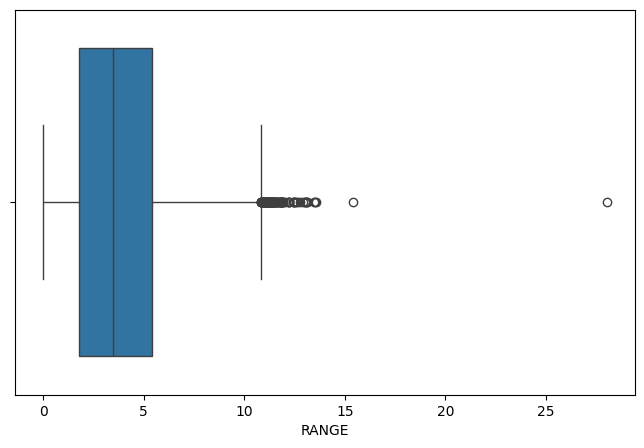

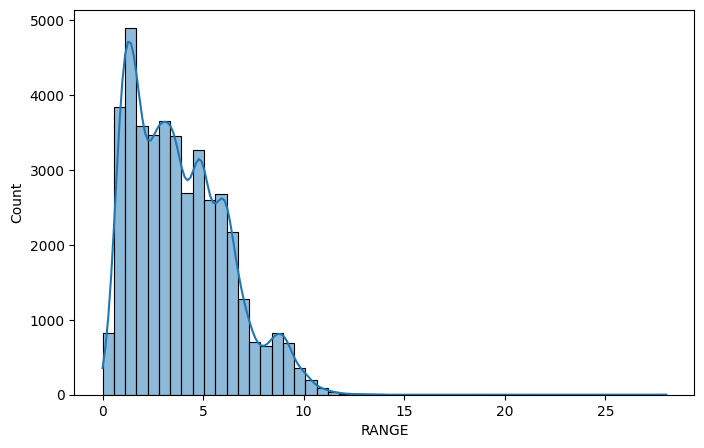

Min: 0.0 Max: 28.02


In [146]:
# Boxplot for RANGE
plt.figure(figsize=(8,5))
sns.boxplot(x=df_cleaned["RANGE"])
plt.show()

# Histogram to check distribution
plt.figure(figsize=(8,5))
sns.histplot(df_cleaned["RANGE"], bins=50, kde=True)
plt.show()

# Check min and max values of RANGE
print("Min:", df_cleaned["RANGE"].min(), "Max:", df_cleaned["RANGE"].max())

In [147]:
Q1 = df_cleaned["RANGE"].quantile(0.25)
Q3 = df_cleaned["RANGE"].quantile(0.75)

# Compute IQR
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = df_cleaned[(df_cleaned["RANGE"] < lower_bound) | (df_cleaned["RANGE"] > upper_bound)]
num_outliers = outliers.shape[0]

print("Number of outliers in RANGE:", num_outliers)

Number of outliers in RANGE: 121


#### **Features: FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3**

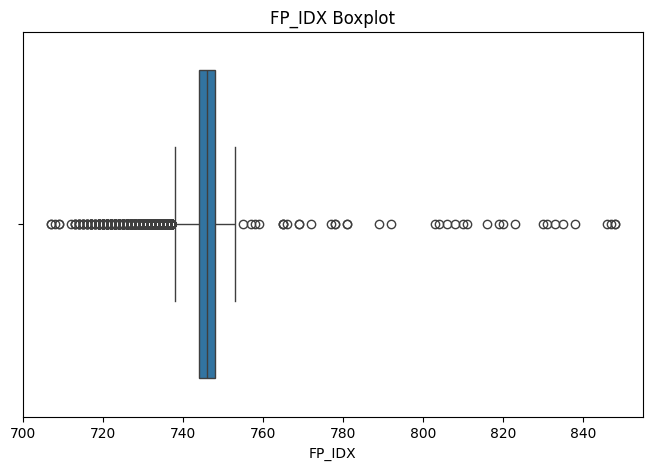

In [148]:
# Plot boxplot for FP_IDX
plt.figure(figsize=(8,5))
sns.boxplot(x=df_cleaned["FP_IDX"])
plt.title("FP_IDX Boxplot")
plt.show()

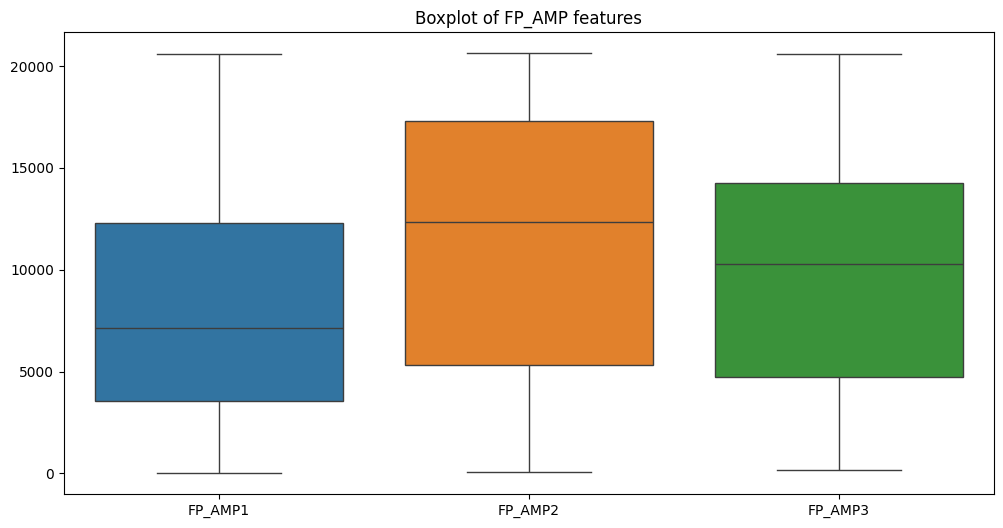

In [149]:
# Plot boxplot for FP_AMP features
# Select features
features = ["FP_AMP1", "FP_AMP2", "FP_AMP3"]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_cleaned[features])
plt.title("Boxplot of FP_AMP features")
plt.show()

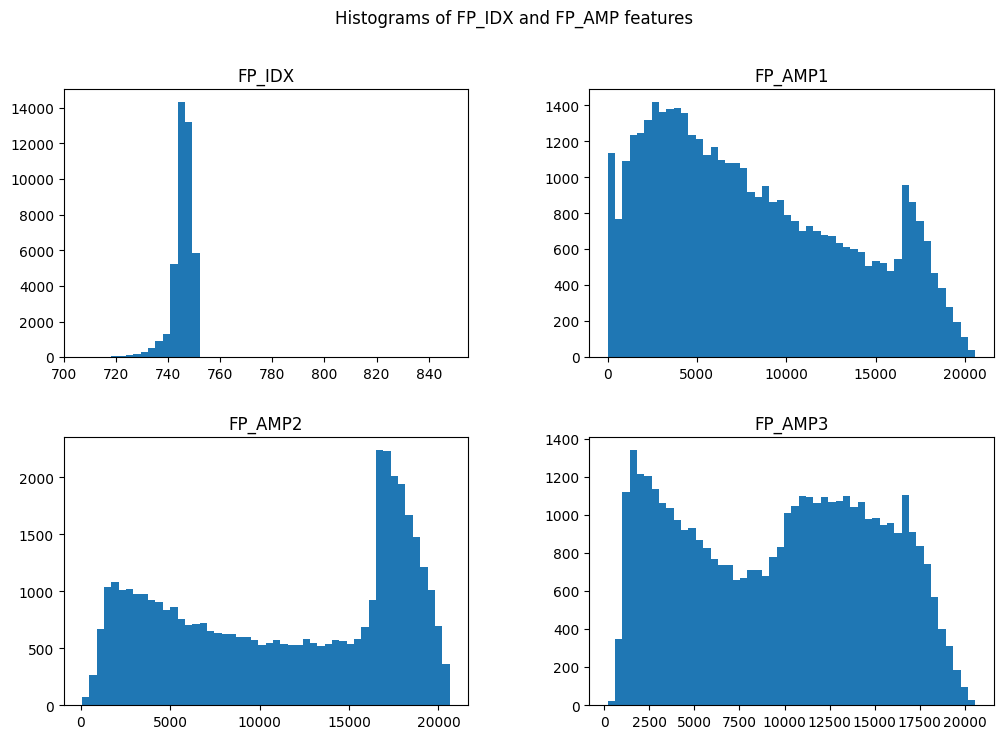

In [150]:
# Plot histogram for FP_IDX and FP_AMP features
# Select features
features = ["FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3"]

df_cleaned[features].hist(bins=50, figsize=(12,8), grid=False)
plt.suptitle("Histograms of FP_IDX and FP_AMP features")
plt.show()

Here, we only remove **extreme outliers** of FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3 that may highly likely be noise, sensor errors, or unusual environmental interfence.

In [151]:
features = ["FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3"]

# Determine Q1 and Q2 of features
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Count outliers per feature
outlier_counts = ((df[features] < lower_bound) | (df[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

# Mask for outliers
outlier_mask = ((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)

# Remove outliers
df_cleaned = df.loc[outlier_mask != True]

print(f"Dataset shape after removing outliers: {df_cleaned.shape}")

Outlier count per feature:
FP_IDX     622
FP_AMP1      0
FP_AMP2      0
FP_AMP3      0
dtype: int64
Total outliers across all features: 622
Dataset shape after removing outliers: (41378, 1031)


#### **Features: STDEV_NOISE, MAX_NOISE**

For STDEV_NOISE and MAX_NOISE, **extreme outliers** are also removed as these can be likely due to sensor glitches or interference.

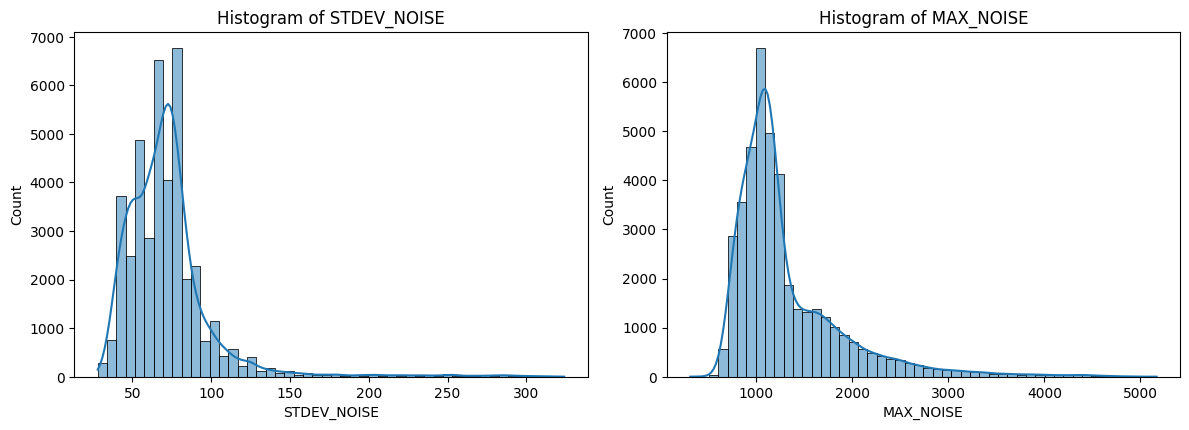

In [152]:
features = ["STDEV_NOISE", "MAX_NOISE"]

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_cleaned[feature], bins=50, kde=True)
    plt.title(f"Histogram of {feature}")

plt.tight_layout()
plt.show()

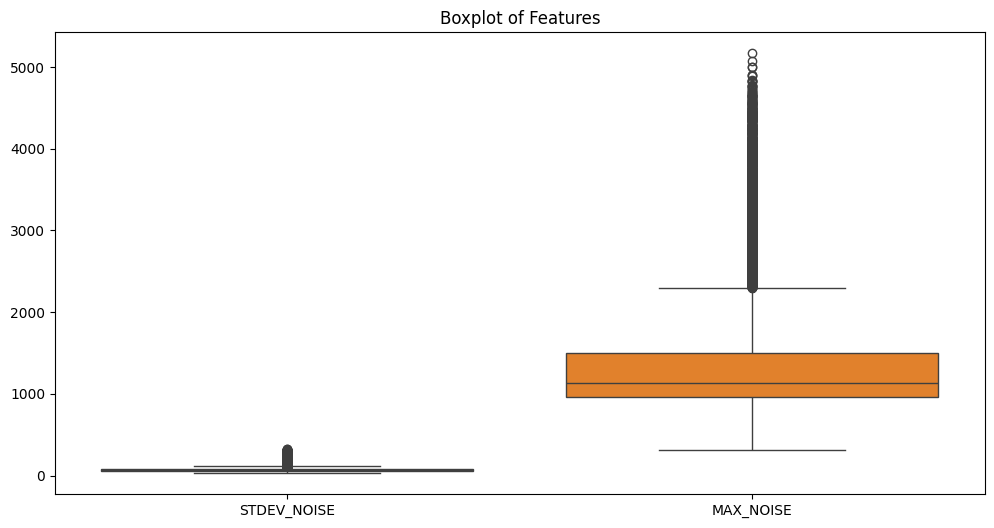

In [153]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_cleaned[features])
plt.title("Boxplot of Features")
plt.show()

In [154]:
# Determine Q1 and Q2 of features
Q1 = df_cleaned[features].quantile(0.25)
Q3 = df_cleaned[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Count outliers per feature
outlier_counts = ((df_cleaned[features] < lower_bound) | (df_cleaned[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print(f'Current dataset shape: {df_cleaned.shape}')
print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

# Mask for outliers
outlier_mask = ((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)

# Remove outliers
df_cleaned = df.loc[outlier_mask != True]

print(f"Dataset shape after removing outliers: {df_cleaned.shape}")

Current dataset shape: (41378, 1031)
Outlier count per feature:
STDEV_NOISE    811
MAX_NOISE      871
dtype: int64
Total outliers across all features: 1682
Dataset shape after removing outliers: (40849, 1031)


#### **Feature: CIR_PWR**

For CIR_PWR, we check for impossible values such as **negative and zero values** as Channel Impulse Response power will never be negative.

In [155]:
print(f'Dataset before cleaning: {df_cleaned.shape}')
impossible_cir_pwr_count = (df_cleaned["CIR_PWR"] <= 0).sum()
print(f"Number of CIR_PWR values ≤ 0: {impossible_cir_pwr_count}")

df_cleaned = df_cleaned[df_cleaned["CIR_PWR"] > 0]
print(f"Dataset shape after removing impossible CIR_PWR values: {df_cleaned.shape}")

Dataset before cleaning: (40849, 1031)
Number of CIR_PWR values ≤ 0: 3
Dataset shape after removing impossible CIR_PWR values: (40846, 1031)


#### **Features: RXPACC, FRAME_LEN, PREAM_LEN, CH, BITRATE, PRFR**

For most of these features, the data should be predefined. Hence, we use a histogram to check for multiple unique values. Besides RXPACC which does not have a predefined value, PREAM_LEN has 2 unique values. 

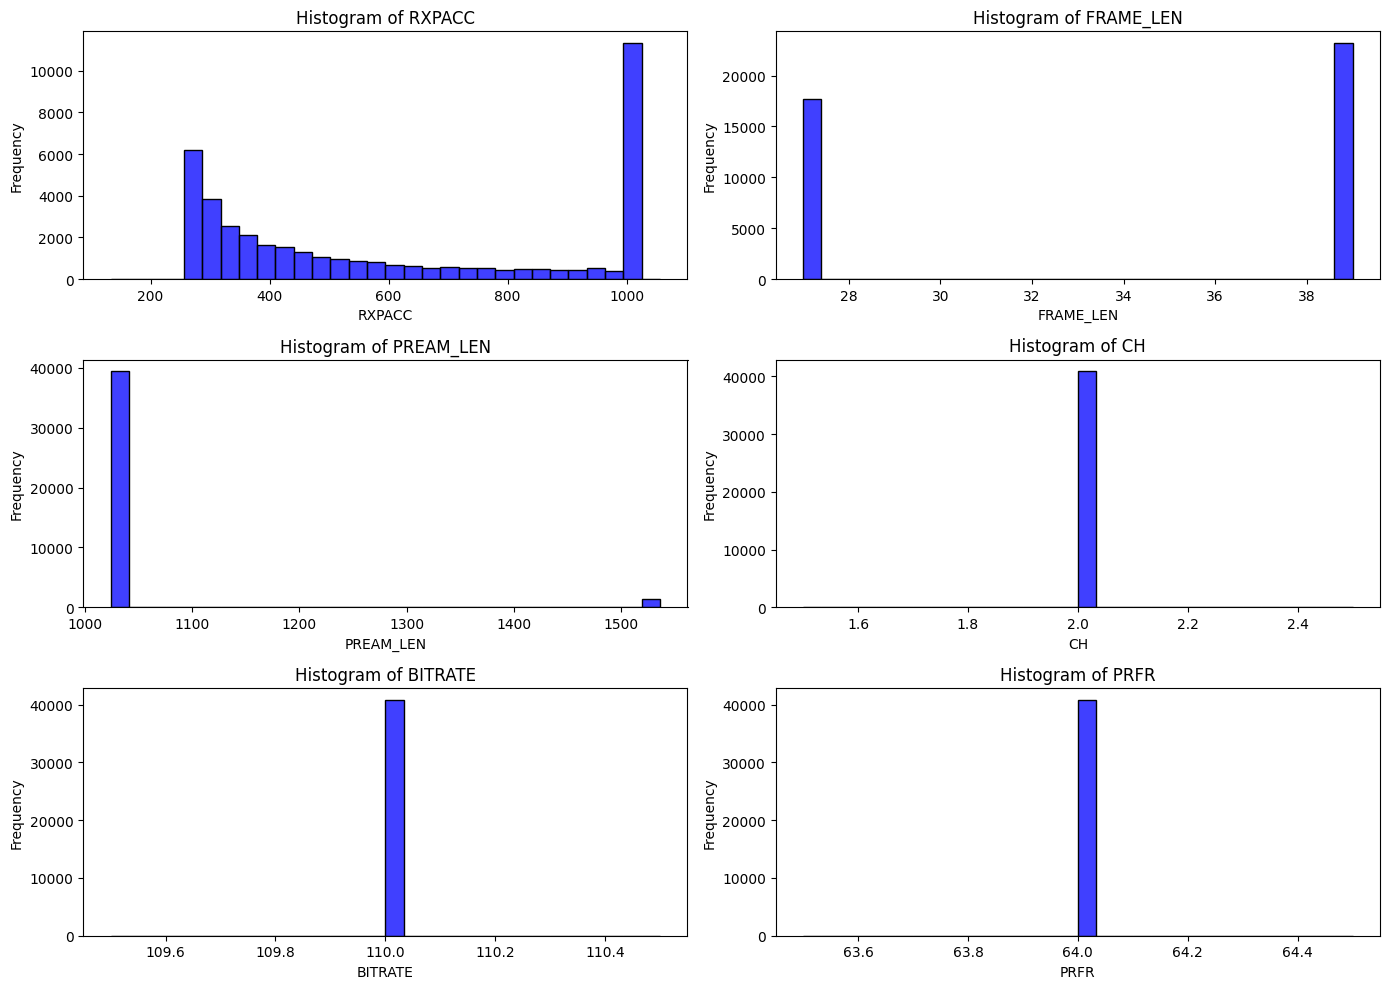

In [156]:
features = ["RXPACC", "FRAME_LEN", "PREAM_LEN", "CH", "BITRATE", "PRFR"]

plt.figure(figsize=(14, 10))

# Loop each feature to plot histogram
for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df_cleaned[feature], bins=30, color="blue")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {feature}")

plt.tight_layout()
plt.show()

To **check for outliers** on RXPACC and PREAM_LEN, we use boxplots to visualize the distribution of data and IQR to count the extreme outliers.

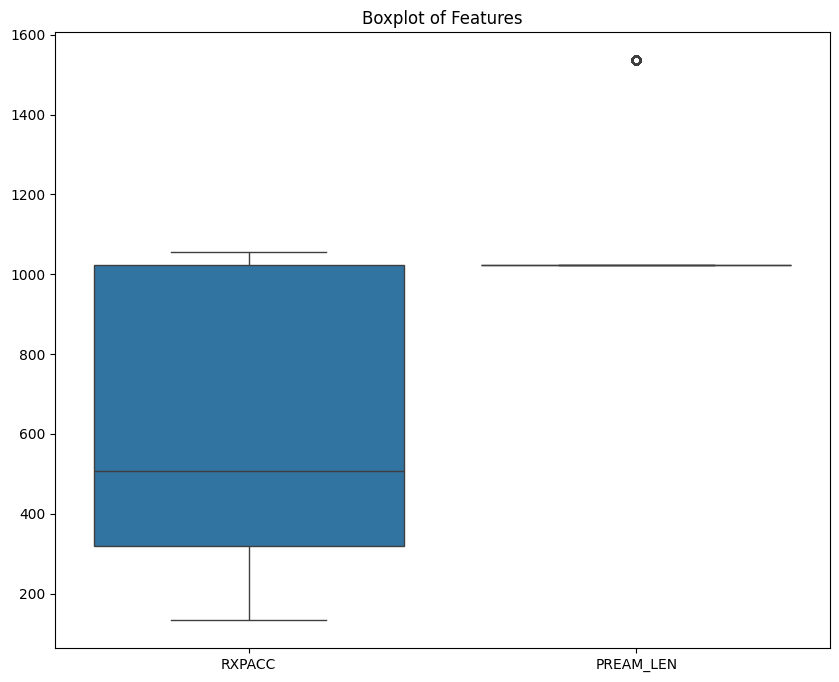

In [157]:
features = ["RXPACC", "PREAM_LEN"]

plt.figure(figsize=(10,8))
sns.boxplot(data=df_cleaned[features])
plt.title("Boxplot of Features")
plt.show()

In [159]:
# Determine Q1 and Q2 of features
Q1 = df_cleaned[features].quantile(0.25)
Q3 = df_cleaned[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Count outliers per feature
outlier_counts = ((df_cleaned[features] < lower_bound) | (df_cleaned[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

Outlier count per feature:
RXPACC          0
PREAM_LEN    1478
dtype: int64
Total outliers across all features: 1478


For futher analysis of PREAM_LEN, we used value_counts(). The output are 2 unique values; 1024.0 and 1536.0. Upon research, 1536 is a valid premeable length so we are **not removing this "outlier"**.

In [160]:
df_cleaned["PREAM_LEN"].value_counts()

PREAM_LEN
1024.0    39368
1536.0     1478
Name: count, dtype: int64

### **Data Preprocessing**

#### **Principal Component Analysis (PCA)**

For features CIR0 to CIR1015 (1016 features), we perfomed **dimensionality reduction using PCA** to reduce the number of CIR features for effective training of our model. This also removes redundancy and transform highly correlated features into a single feature to improve model performance. 

As seen below, we managed to reduce CIR's dimensions by 136 dimensions using PCA.

In [162]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print(f'Shape before PCA: {df_cleaned.shape}')

# Step 1: Extract CIR Features
cir_features = [f"CIR{i}" for i in range(1016)]
X_cir = df_cleaned[cir_features]  
original_features = X_cir.shape[1]  # Number of features in original dataset

# Step 2: Standardize the Data (PCA requires normalization)
scaler = StandardScaler()
X_cir_scaled = scaler.fit_transform(X_cir)

pca = PCA(n_components=0.95)  # Keep 95% variance
X_cir_pca = pca.fit_transform(X_cir_scaled)
reduced_features = X_cir_pca.shape[1]   # Number of features after PCA

# Print PCA results
print(f"New shape of transformed data: {X_cir_pca.shape}")
print(f"Number of features before PCA: {original_features}")
print(f"Number of features after PCA: {reduced_features}")
print(f"Number of features removed: {original_features - reduced_features}")

Shape before PCA: (40846, 1031)
New shape of transformed data: (40846, 880)
Number of features before PCA: 1016
Number of features after PCA: 880
Number of features removed: 136


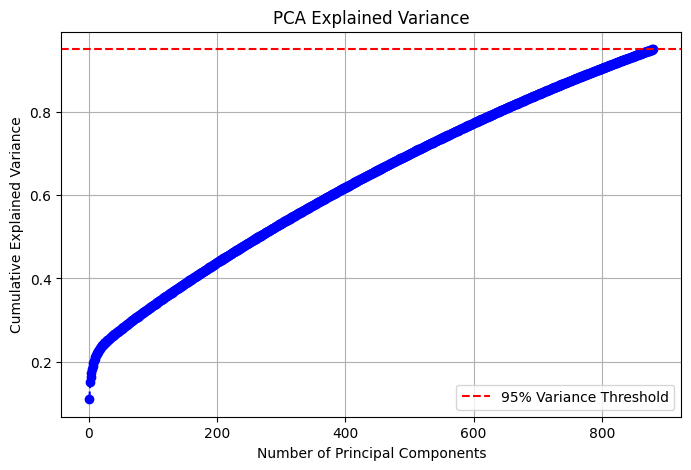

In [165]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)
plt.show()


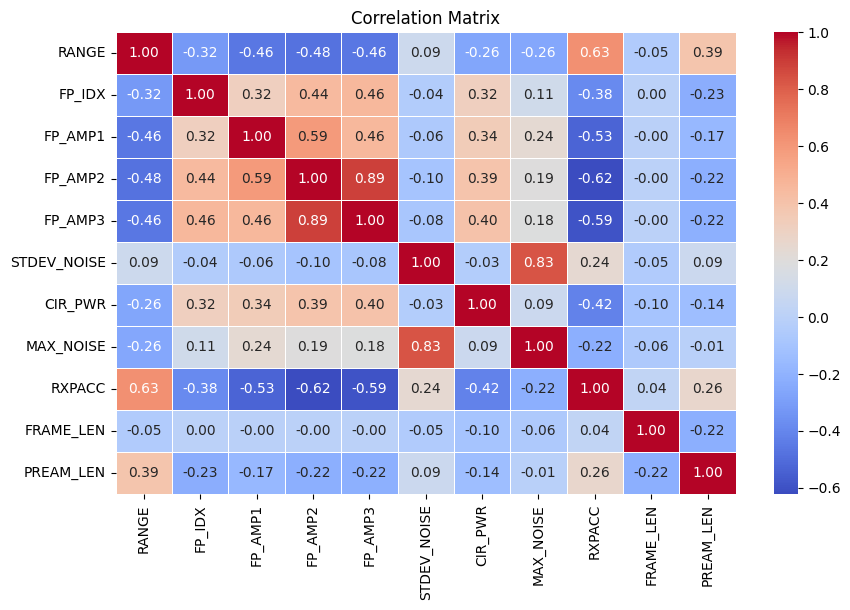

In [20]:
# Shortlisted features to check correlation with each other
features = ['RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
            'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
            'FRAME_LEN','PREAM_LEN']

# Compute the correlation matrix
correlation_matrix = df[features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()